# 2. Dataset Overview and Data Loading

Dataset metadata, image discovery, two-digit label construction, and dataset inspection.



# EN3150 Assignment 03 — Two-Digit MNIST Classification

## Resource-Constrained CNN for Edge Image Classification

This notebook implements the assignment using the **MNIST 2 Digit Dataset**.

### Classification problem
Each image contains two handwritten digits. The CSV provides:

- `file_name`
- `label_1`
- `label_2`

The two labels are combined into a single **100-class target**:

`00, 01, 02, ..., 98, 99`

For example:
- `label_1=1`, `label_2=3` → class `13`
- `label_1=6`, `label_2=6` → class `66`

### Assignment requirements covered
1. Data preparation: maximum **64×64**, **70/15/15** split.
2. **Model A:** standard Conv2D + MaxPooling CNN.
3. **Model B:** depthwise-separable CNN with **<100,000 trainable parameters**.
4. Optimizer comparison: selected optimizer vs SGD vs SGD + Momentum.
5. Train custom models for **at least 20 epochs** and evaluate accuracy, precision, recall and confusion matrix.
6. Compare parameter count, model size and training time.
7. Fine-tune two lightweight pretrained models: **MobileNetV2** and **EfficientNet-B0**.
8. Final accuracy / memory / computational-cost comparison.

> This notebook uses the CSV labels instead of assuming numeric class folders. This fixes the `ValueError: Images were found, but no numeric class folders were detected` problem.


# 1. Project Setup

Imports, reproducibility settings, device configuration, and project paths.


In [1]:

# Optional: install missing packages in a Jupyter/VS Code notebook.
# Run this cell only if imports below fail.

# %pip install torch torchvision pandas numpy matplotlib scikit-learn pillow tqdm


# 3. Dataset Pre-Processing and Train/Validation/Test Split

Image preprocessing and the 70% / 15% / 15% stratified split.


In [2]:

import os
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu126
Torchvision: 0.25.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 2050



## 1. Configuration

Change only `DATA_DIR` if your dataset is stored somewhere else.

The code automatically searches for `train.csv` and `test.csv`, and recursively indexes PNG/JPG/JPEG images.


# 7. Optimizer Comparison

Five-epoch comparison of Adam, SGD, and SGD with Momentum.


In [3]:

# ============================================================
# CHANGE THIS PATH IF NECESSARY
# ============================================================

DATA_DIR = Path(r"C:\Users\dilha\Downloads\archive")

# Windows example:
# DATA_DIR = Path(r"C:\Users\Sandeepa\Desktop\EN3150_Project\mnist-2-digit-dataset")

IMAGE_SIZE = 64
NUM_CLASSES = 100

BATCH_SIZE = 128 if torch.cuda.is_available() else 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

MAIN_EPOCHS = 20
OPTIMIZER_COMPARE_EPOCHS = 5

LEARNING_RATE = 1e-3
MOMENTUM = 0.9

# Set these to False if you want to skip the long SOTA stage initially.
RUN_MOBILENET = True
RUN_EFFICIENTNET = True
SOTA_EPOCHS = 20

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)


DATA_DIR: C:\Users\dilha\Downloads\archive
IMAGE_SIZE: 64
BATCH_SIZE: 128


## 2. Verify the dataset structure

In [4]:

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"DATA_DIR does not exist: {DATA_DIR.resolve()}\n"
        "Please download/extract the Kaggle MNIST 2 Digit Dataset and update DATA_DIR."
    )

print("Dataset contents:")
for item in sorted(DATA_DIR.iterdir()):
    print(" -", item.name)

print("\nCSV files found:")
for p in DATA_DIR.rglob("*.csv"):
    print(" -", p)


Dataset contents:
 - test
 - test.csv
 - train
 - train.csv

CSV files found:
 - C:\Users\dilha\Downloads\archive\test.csv
 - C:\Users\dilha\Downloads\archive\train.csv



## 3. Load the CSV files

The Kaggle dataset shown in the screenshot has `file_name`, `label_1`, and `label_2`.

We deliberately **do not** use `ImageFolder`, because this dataset does not use folders named `0`, `1`, ..., `9`.


In [5]:

def find_csv(filename):
    matches = list(DATA_DIR.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} inside {DATA_DIR.resolve()}"
        )
    return matches[0]

train_csv = find_csv("train.csv")
test_csv = find_csv("test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("train.csv:", train_csv)
print("test.csv :", test_csv)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

display(train_df.head())


train.csv: C:\Users\dilha\Downloads\archive\train.csv
test.csv : C:\Users\dilha\Downloads\archive\test.csv

Train shape: (55000, 3)
Test shape : (5000, 3)

Train columns: ['file_name', 'label_1', 'label_2']
Test columns : ['file_name', 'label_1', 'label_2']


,file_name,label_1,label_2
0,00000_3_7.png,3,7
1,00001_0_5.png,0,5
2,00002_4_4.png,4,4
3,00003_5_9.png,5,9
4,00004_0_8.png,0,8


### Check the required columns

In [6]:

required_columns = {"file_name", "label_1", "label_2"}

for name, df in [("train.csv", train_df), ("test.csv", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}. "
            f"Found columns: {df.columns.tolist()}"
        )

print("Required columns are present.")


Required columns are present.


## 4. Create the 100-class two-digit target

In [7]:

def create_two_digit_label(df):
    df = df.copy()

    df["label_1"] = pd.to_numeric(df["label_1"], errors="raise").astype(int)
    df["label_2"] = pd.to_numeric(df["label_2"], errors="raise").astype(int)

    if not df["label_1"].between(0, 9).all():
        raise ValueError("label_1 contains values outside 0-9.")
    if not df["label_2"].between(0, 9).all():
        raise ValueError("label_2 contains values outside 0-9.")

    df["label"] = df["label_1"] * 10 + df["label_2"]
    return df

train_df = create_two_digit_label(train_df)
test_df = create_two_digit_label(test_df)

print("Example labels:")
display(train_df[["file_name", "label_1", "label_2", "label"]].head(15))


Example labels:


,file_name,label_1,label_2,label
0,00000_3_7.png,3,7,37
1,00001_0_5.png,0,5,5
2,00002_4_4.png,4,4,44
3,00003_5_9.png,5,9,59
4,00004_0_8.png,0,8,8
5,00005_5_6.png,5,6,56
6,00006_0_7.png,0,7,7
7,00007_0_3.png,0,3,3
8,00008_5_6.png,5,6,56
9,00009_8_8.png,8,8,88


## 5. Index all image files

In [8]:

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}

image_lookup = {}

for path in DATA_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        image_lookup[path.name] = str(path)

print("Images indexed:", len(image_lookup))

print("\nFirst 10 image paths:")
for name, path in list(image_lookup.items())[:10]:
    print(name, "->", path)

def add_image_path(df):
    df = df.copy()
    df["image_path"] = df["file_name"].map(image_lookup)
    missing = df["image_path"].isna().sum()

    if missing:
        examples = df.loc[df["image_path"].isna(), "file_name"].head(10).tolist()
        raise FileNotFoundError(
            f"{missing} image files from the CSV were not found. "
            f"Examples: {examples}"
        )
    return df

train_df = add_image_path(train_df)
test_df = add_image_path(test_df)

print("\nAll CSV image filenames were matched successfully.")


Images indexed: 59896

First 10 image paths:
00000_3_5.png -> C:\Users\dilha\Downloads\archive\test\00000_3_5.png
00001_1_8.png -> C:\Users\dilha\Downloads\archive\test\00001_1_8.png
00002_2_6.png -> C:\Users\dilha\Downloads\archive\test\00002_2_6.png
00003_7_8.png -> C:\Users\dilha\Downloads\archive\test\00003_7_8.png
00004_2_4.png -> C:\Users\dilha\Downloads\archive\test\00004_2_4.png
00005_8_9.png -> C:\Users\dilha\Downloads\archive\test\00005_8_9.png
00006_1_3.png -> C:\Users\dilha\Downloads\archive\test\00006_1_3.png
00007_1_4.png -> C:\Users\dilha\Downloads\archive\test\00007_1_4.png
00008_6_7.png -> C:\Users\dilha\Downloads\archive\test\00008_6_7.png
00009_8_9.png -> C:\Users\dilha\Downloads\archive\test\00009_8_9.png

All CSV image filenames were matched successfully.


# 4. Dataset Sample Images

Generate and inspect representative samples for the report figure.


## 6. Visualize the actual two-digit images

# 11. Report Figures and Results Export

Save plots, CSV results, model weights, and other artifacts needed by the LaTeX report.


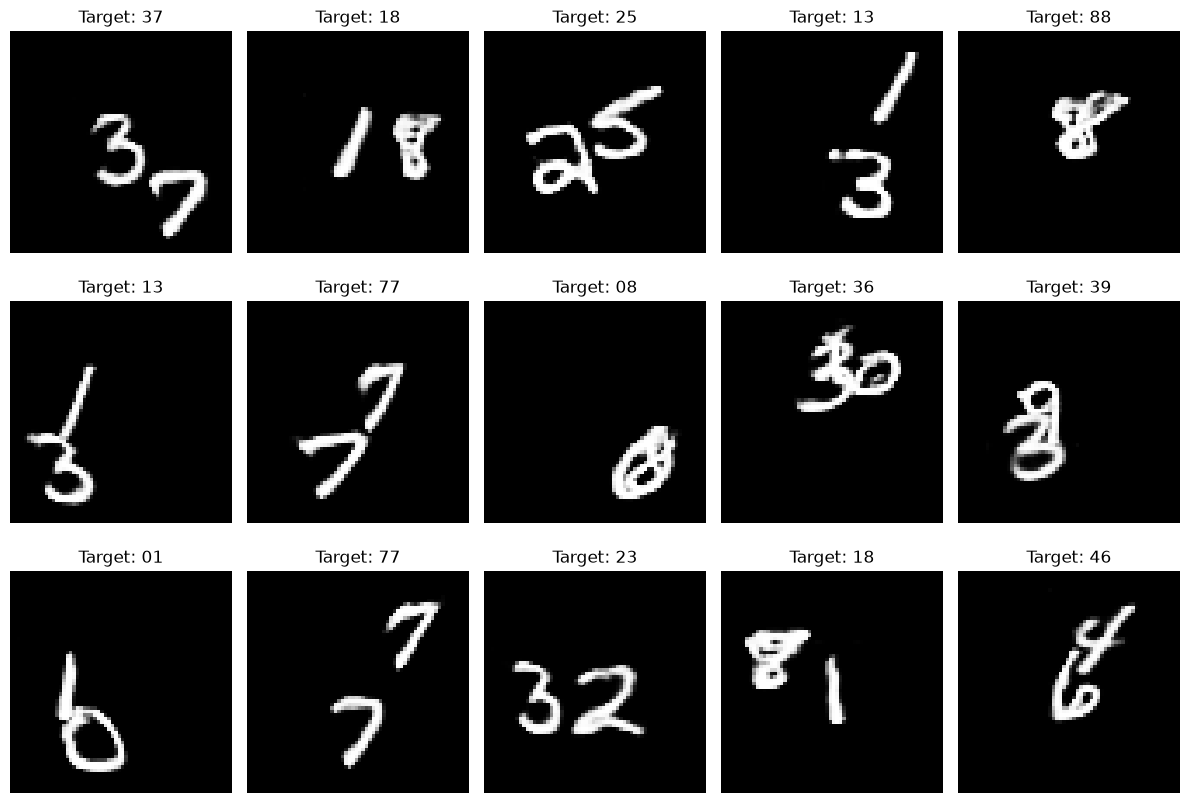

In [9]:

def show_samples(df, n=15, seed=SEED):
    sample_df = df.sample(n=min(n, len(df)), random_state=seed)

    rows = int(np.ceil(len(sample_df) / 5))
    fig, axes = plt.subplots(rows, 5, figsize=(12, 2.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("L")
        ax.imshow(image, cmap="gray")
        ax.set_title(f"Target: {row['label']:02d}")
        ax.axis("off")

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, n=15)


# 10. Final Model Comparison

Compare parameters, model size, time per epoch, accuracy, precision, and recall.



## 7. Build the 70/15/15 split

The assignment requires 70% training, 15% validation and 15% testing.

Because this Kaggle dataset already has `train.csv` and `test.csv`, this notebook combines the labelled rows and creates the required assignment split itself. This makes the final experiment exactly 70/15/15.

A stratified split is used so that the 100 two-digit classes remain as balanced as possible.


In [10]:

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df = all_df.drop_duplicates(subset=["file_name"]).reset_index(drop=True)

print("Total labelled images:", len(all_df))
print("Unique filenames:", all_df["file_name"].nunique())

train_split, temp_split = train_test_split(
    all_df,
    test_size=0.30,
    random_state=SEED,
    stratify=all_df["label"],
)

val_split, test_split = train_test_split(
    temp_split,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_split["label"],
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
test_split = test_split.reset_index(drop=True)

print("Train:", len(train_split), f"({len(train_split)/len(all_df)*100:.2f}%)")
print("Val  :", len(val_split), f"({len(val_split)/len(all_df)*100:.2f}%)")
print("Test :", len(test_split), f"({len(test_split)/len(all_df)*100:.2f}%)")


Total labelled images: 59896
Unique filenames: 59896
Train: 41927 (70.00%)
Val  : 8984 (15.00%)
Test : 8985 (15.00%)


### Check class distribution

In [11]:

class_counts = pd.DataFrame({
    "train": train_split["label"].value_counts().sort_index(),
    "validation": val_split["label"].value_counts().sort_index(),
    "test": test_split["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(class_counts.head(20))

print("Number of classes represented:", all_df["label"].nunique())
print("Expected number of classes:", NUM_CLASSES)


,train,validation,test
label,,,
0,431,92,92
1,816,175,174
2,842,180,181
3,874,187,187
4,843,181,181
5,848,181,182
6,861,184,185
7,839,180,180
8,829,178,178


Number of classes represented: 55
Expected number of classes: 100



## 8. Image preprocessing

All images are resized to **64×64**, satisfying the assignment's maximum resolution.

Pixel values are converted to tensors and normalized to approximately [-1, 1].


In [12]:

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


## 9. PyTorch Dataset

In [13]:

class TwoDigitDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("L")

        if self.transform:
            image = self.transform(image)

        label = int(row["label"])
        return image, label


train_dataset = TwoDigitDataset(train_split, train_transform)
val_dataset = TwoDigitDataset(val_split, transform)
test_dataset = TwoDigitDataset(test_split, transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 328
Validation batches: 71
Test batches: 71


### Check one batch

Image batch shape: torch.Size([128, 1, 64, 64])
Label batch shape: torch.Size([128])
Example labels: ['45', '26', '59', '19', '89', '39', '17', '36', '99', '13']


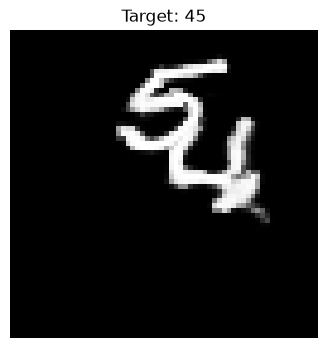

In [14]:

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Example labels:", [f"{x:02d}" for x in labels[:10].tolist()])

plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze().numpy(), cmap="gray")
plt.title(f"Target: {labels[0].item():02d}")
plt.axis("off")
plt.show()


# 5. Custom CNN — Model A

Standard CNN architecture, parameter count, training, validation, and test evaluation.



# 10. Model A — Standard CNN

Architecture:

- Conv 3×3, 16 filters
- MaxPool
- Conv 3×3, 32 filters
- MaxPool
- Conv 3×3, 64 filters
- MaxPool
- Flatten
- Dense 128
- 100-class output

ReLU is used because it is simple and computationally cheap for an edge-oriented CNN.
The final layer returns logits; softmax is handled internally by `CrossEntropyLoss`.


In [15]:

class StandardCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_a = StandardCNN().to(device)
print(model_a)


StandardCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=100, bias=True)
  )
)


# 6. Resource-Constrained CNN — Model B

Depthwise-separable CNN, sub-100,000 parameter constraint, training, and evaluation.


## 11. Model B — Lightweight Depthwise-Separable CNN

In [16]:

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()

        padding = kernel_size // 2

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_channels,
            bias=False,
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1,
            bias=False,
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class LightweightCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            DepthwiseSeparableConv(1, 16),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(16, 32),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model_b = LightweightCNN().to(device)
print(model_b)


LightweightCNN(
  (features): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (pointwise): Conv2d(1, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DepthwiseSeparableConv(
      (depthwise): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
      (pointwise): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 

## 12. Parameter counts — verify Model B is below 100,000

In [17]:

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_all_parameters(model):
    return sum(p.numel() for p in model.parameters())

params_a = count_parameters(model_a)
params_b = count_parameters(model_b)

print(f"Model A trainable parameters: {params_a:,}")
print(f"Model B trainable parameters: {params_b:,}")

assert params_b < 100_000, (
    f"Model B has {params_b:,} parameters, which violates the <100,000 requirement."
)

print("\nPASS: Model B is below 100,000 trainable parameters.")


Model A trainable parameters: 560,612
Model B trainable parameters: 9,741

PASS: Model B is below 100,000 trainable parameters.



### Why Model B is lightweight

A standard convolution connects every input channel to every output channel.

A depthwise-separable convolution splits this into:

1. **Depthwise convolution:** one spatial filter per input channel.
2. **Pointwise 1×1 convolution:** mixes channels.

Global Average Pooling also avoids a large fully connected layer.


# 13. Training and evaluation utilities

# 8. Confusion Matrices and Detailed Evaluation

Accuracy, macro precision, macro recall, and confusion-matrix analysis.


In [18]:

criterion = nn.CrossEntropyLoss()


def create_optimizer(model, name, lr=LEARNING_RATE, momentum=MOMENTUM):
    name = name.lower()

    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)

    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)

    if name in ["sgd_momentum", "momentum"]:
        return optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum
        )

    raise ValueError(f"Unknown optimizer: {name}")


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_targets, all_predictions)

    return epoch_loss, epoch_accuracy


def train_model(model, train_loader, val_loader, epochs,
                optimizer_name="adam", lr=LEARNING_RATE,
                momentum=MOMENTUM, model_name="model"):

    model = model.to(device)

    optimizer = create_optimizer(
        model, optimizer_name, lr=lr, momentum=momentum
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1.0

    total_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = run_epoch(
            model, val_loader, criterion
        )

        epoch_time = time.perf_counter() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Time: {epoch_time:.1f}s"
        )

    total_time = time.perf_counter() - total_start

    model.load_state_dict(best_state)

    history["total_time"] = total_time
    history["avg_epoch_time"] = total_time / epochs
    history["best_val_accuracy"] = best_val_accuracy

    return model, history


@torch.no_grad()
def predict_model(model, loader):
    model.eval()

    all_predictions = []
    all_targets = []

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)

        outputs = model(inputs)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.numpy())

    return np.array(all_targets), np.array(all_predictions)


def evaluate_model(model, loader, model_name="Model"):
    y_true, y_pred = predict_model(model, loader)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(
        y_true, y_pred, labels=np.arange(NUM_CLASSES)
    )

    print(f"\n{model_name} Test Results")
    print("=" * 50)
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}% (macro)")
    print(f"Recall   : {recall*100:.2f}% (macro)")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        np.array(history["train_accuracy"]) * 100,
        label="Training accuracy"
    )
    plt.plot(
        epochs,
        np.array(history["val_accuracy"]) * 100,
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def save_model_size(model, filename):
    path = OUTPUT_DIR / filename
    torch.save(model.state_dict(), path)
    size_kb = path.stat().st_size / 1024
    size_mb = size_kb / 1024
    return path, size_kb, size_mb



# 14. Optimizer comparison

The assignment asks us to compare the selected optimizer against:

- Standard SGD
- SGD with Momentum

Adam is used as the main optimizer initially because it adapts the update scale for each parameter and often converges quickly.

For the tuning comparison we use a short run. The final custom models are then trained for the required 20 epochs.


In [19]:

optimizer_results = []

for optimizer_name in ["sgd", "sgd_momentum", "adam"]:
    print("\n" + "=" * 70)
    print("Optimizer:", optimizer_name)

    seed_everything()

    temp_model = LightweightCNN().to(device)

    if optimizer_name == "sgd":
        lr = 0.01
    elif optimizer_name == "sgd_momentum":
        lr = 0.01
    else:
        lr = 0.001

    temp_model, temp_history = train_model(
        temp_model,
        train_loader,
        val_loader,
        epochs=OPTIMIZER_COMPARE_EPOCHS,
        optimizer_name=optimizer_name,
        lr=lr,
        momentum=MOMENTUM,
        model_name=f"Model B - {optimizer_name}",
    )

    optimizer_results.append({
        "Optimizer": optimizer_name,
        "Learning Rate": lr,
        "Momentum": MOMENTUM if optimizer_name == "sgd_momentum" else 0.0,
        "Best Validation Accuracy (%)":
            temp_history["best_val_accuracy"] * 100,
        "Average Epoch Time (s)":
            temp_history["avg_epoch_time"],
    })

optimizer_results_df = pd.DataFrame(optimizer_results)
display(optimizer_results_df)



Optimizer: sgd
Model B - sgd | Epoch 01/5 | Train Loss: 4.3951 | Train Acc: 1.70% | Val Loss: 4.2122 | Val Acc: 2.16% | Time: 54.2s
Model B - sgd | Epoch 02/5 | Train Loss: 4.1294 | Train Acc: 2.46% | Val Loss: 4.0737 | Val Acc: 3.07% | Time: 53.2s
Model B - sgd | Epoch 03/5 | Train Loss: 4.0414 | Train Acc: 3.03% | Val Loss: 4.0147 | Val Acc: 4.27% | Time: 61.8s
Model B - sgd | Epoch 04/5 | Train Loss: 3.9981 | Train Acc: 3.91% | Val Loss: 3.9802 | Val Acc: 4.52% | Time: 52.1s
Model B - sgd | Epoch 05/5 | Train Loss: 3.9690 | Train Acc: 4.47% | Val Loss: 3.9521 | Val Acc: 5.82% | Time: 46.3s

Optimizer: sgd_momentum
Model B - sgd_momentum | Epoch 01/5 | Train Loss: 4.0206 | Train Acc: 3.72% | Val Loss: 3.8087 | Val Acc: 5.92% | Time: 45.8s
Model B - sgd_momentum | Epoch 02/5 | Train Loss: 3.6305 | Train Acc: 8.66% | Val Loss: 3.4542 | Val Acc: 11.28% | Time: 51.5s
Model B - sgd_momentum | Epoch 03/5 | Train Loss: 3.2692 | Train Acc: 14.72% | Val Loss: 3.0216 | Val Acc: 21.36% | Time:

,Optimizer,Learning Rate,Momentum,Best Validation Accuracy (%),Average Epoch Time (s)
0,sgd,0.010,0.0,5.821460,53.490514
1,sgd_momentum,0.010,0.9,21.360196,46.760384
2,adam,0.001,0.0,8.414960,49.727685



### Momentum interpretation for the report

Momentum adds a fraction of the previous update to the current gradient update. This can reduce oscillation and help SGD move more consistently in a useful direction.

In the results table, compare whether `SGD + Momentum` reaches higher validation accuracy or converges faster than plain SGD. Do not claim that momentum is always better; use the measured results from this experiment.


# 15. Train Model A for 20 epochs

Model A - Standard CNN | Epoch 01/20 | Train Loss: 3.6885 | Train Acc: 5.74% | Val Loss: 3.0066 | Val Acc: 14.61% | Time: 51.6s
Model A - Standard CNN | Epoch 02/20 | Train Loss: 1.9479 | Train Acc: 41.20% | Val Loss: 1.0868 | Val Acc: 67.13% | Time: 49.2s
Model A - Standard CNN | Epoch 03/20 | Train Loss: 0.9981 | Train Acc: 69.09% | Val Loss: 0.8057 | Val Acc: 74.24% | Time: 50.7s
Model A - Standard CNN | Epoch 04/20 | Train Loss: 0.7440 | Train Acc: 76.91% | Val Loss: 0.5715 | Val Acc: 82.16% | Time: 51.8s
Model A - Standard CNN | Epoch 05/20 | Train Loss: 0.5969 | Train Acc: 81.05% | Val Loss: 0.4440 | Val Acc: 86.16% | Time: 52.9s
Model A - Standard CNN | Epoch 06/20 | Train Loss: 0.5040 | Train Acc: 83.86% | Val Loss: 0.4192 | Val Acc: 86.35% | Time: 52.2s
Model A - Standard CNN | Epoch 07/20 | Train Loss: 0.4401 | Train Acc: 85.83% | Val Loss: 0.3635 | Val Acc: 88.15% | Time: 52.2s
Model A - Standard CNN | Epoch 08/20 | Train Loss: 0.3850 | Train Acc: 87.56% | Val Loss: 0.3576 |

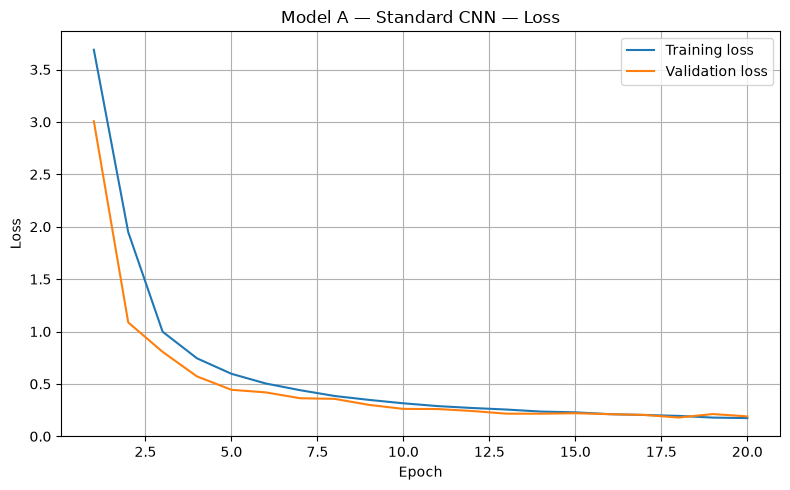

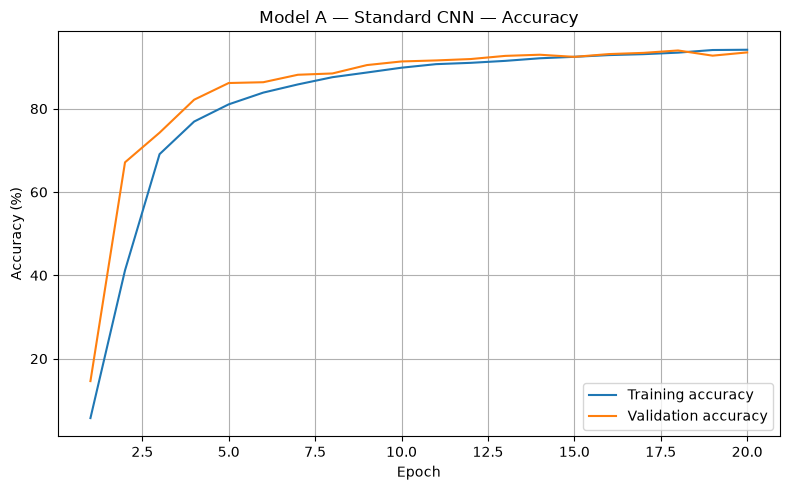

In [20]:

seed_everything()

model_a = StandardCNN().to(device)

model_a, history_a = train_model(
    model_a,
    train_loader,
    val_loader,
    epochs=MAIN_EPOCHS,
    optimizer_name="adam",
    lr=LEARNING_RATE,
    model_name="Model A - Standard CNN",
)

plot_history(history_a, "Model A — Standard CNN")


In [21]:

results_a = evaluate_model(
    model_a,
    test_loader,
    model_name="Model A — Standard CNN"
)



Model A — Standard CNN Test Results
Accuracy : 93.85%
Precision: 93.88% (macro)
Recall   : 93.75% (macro)


## Model A confusion matrix

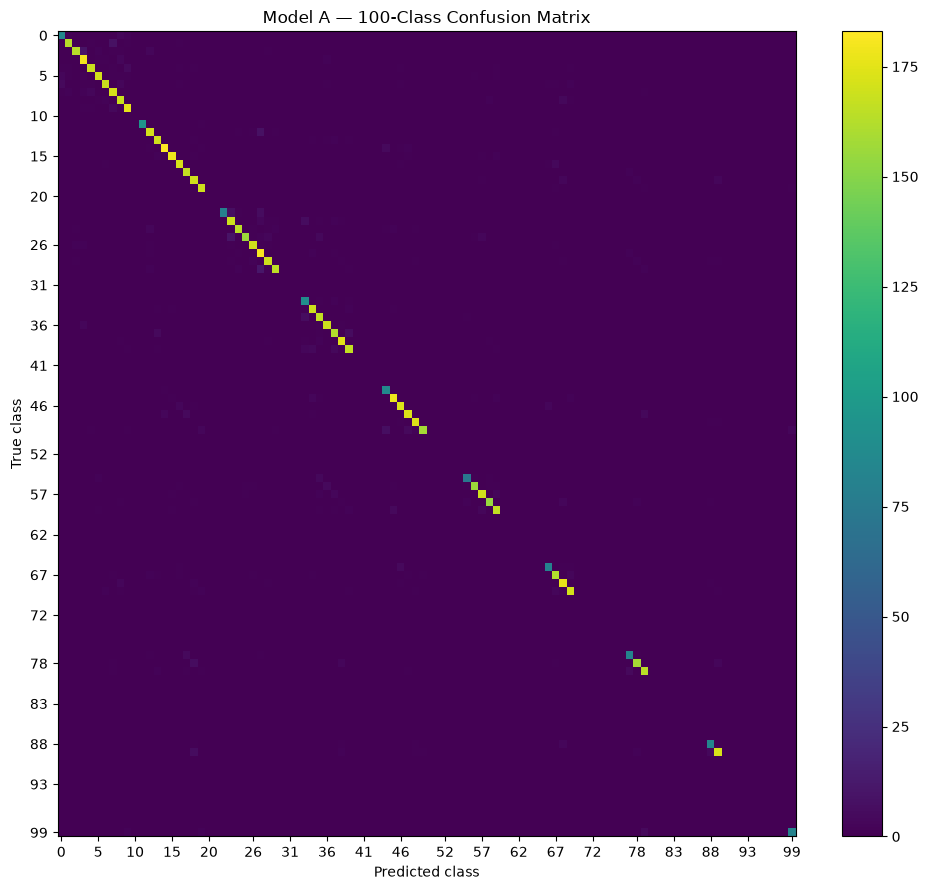

In [22]:

def plot_confusion_matrix(cm, title, max_labels=None):
    plt.figure(figsize=(10, 9))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.colorbar()

    if max_labels is not None and max_labels <= cm.shape[0]:
        ticks = np.linspace(0, cm.shape[0]-1, max_labels, dtype=int)
        plt.xticks(ticks)
        plt.yticks(ticks)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    results_a["confusion_matrix"],
    "Model A — 100-Class Confusion Matrix",
    max_labels=20
)



# 16. Train Model B for 20 epochs

This is the required lightweight model. The parameter count was already verified to be below 100,000.


Model B - Lightweight CNN | Epoch 01/20 | Train Loss: 3.8680 | Train Acc: 5.79% | Val Loss: 3.6366 | Val Acc: 7.77% | Time: 50.9s
Model B - Lightweight CNN | Epoch 02/20 | Train Loss: 3.3073 | Train Acc: 16.04% | Val Loss: 5.2953 | Val Acc: 4.65% | Time: 51.6s
Model B - Lightweight CNN | Epoch 03/20 | Train Loss: 2.7533 | Train Acc: 28.72% | Val Loss: 4.2069 | Val Acc: 7.99% | Time: 52.9s
Model B - Lightweight CNN | Epoch 04/20 | Train Loss: 2.2648 | Train Acc: 42.63% | Val Loss: 9.1465 | Val Acc: 2.72% | Time: 51.6s
Model B - Lightweight CNN | Epoch 05/20 | Train Loss: 1.8960 | Train Acc: 51.84% | Val Loss: 6.1278 | Val Acc: 6.67% | Time: 52.0s
Model B - Lightweight CNN | Epoch 06/20 | Train Loss: 1.6478 | Train Acc: 57.71% | Val Loss: 11.0603 | Val Acc: 4.78% | Time: 51.7s
Model B - Lightweight CNN | Epoch 07/20 | Train Loss: 1.4779 | Train Acc: 61.53% | Val Loss: 7.4723 | Val Acc: 5.00% | Time: 52.3s
Model B - Lightweight CNN | Epoch 08/20 | Train Loss: 1.3484 | Train Acc: 64.25% | 

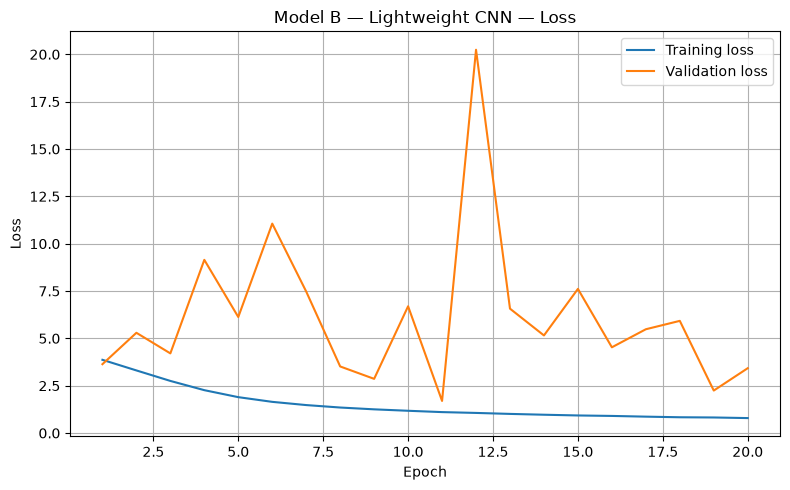

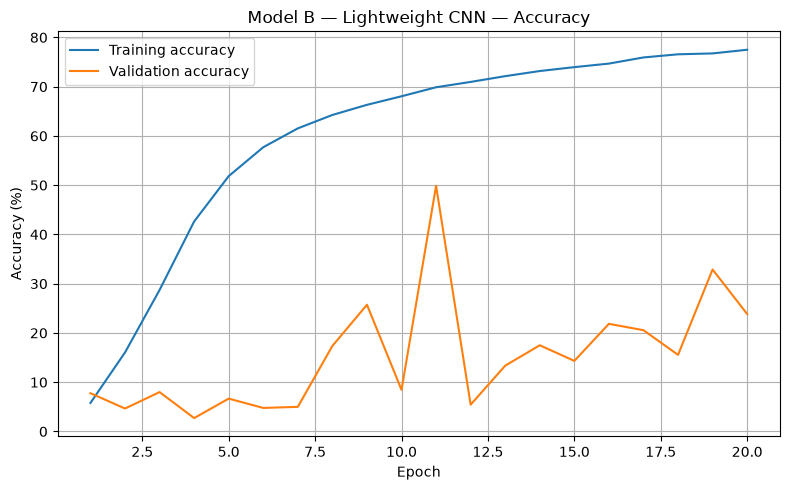

In [23]:

seed_everything()

model_b = LightweightCNN().to(device)

model_b, history_b = train_model(
    model_b,
    train_loader,
    val_loader,
    epochs=MAIN_EPOCHS,
    optimizer_name="adam",
    lr=LEARNING_RATE,
    model_name="Model B - Lightweight CNN",
)

plot_history(history_b, "Model B — Lightweight CNN")


In [24]:

results_b = evaluate_model(
    model_b,
    test_loader,
    model_name="Model B — Lightweight CNN"
)



Model B — Lightweight CNN Test Results
Accuracy : 49.23%
Precision: 60.06% (macro)
Recall   : 49.55% (macro)


## Model B confusion matrix

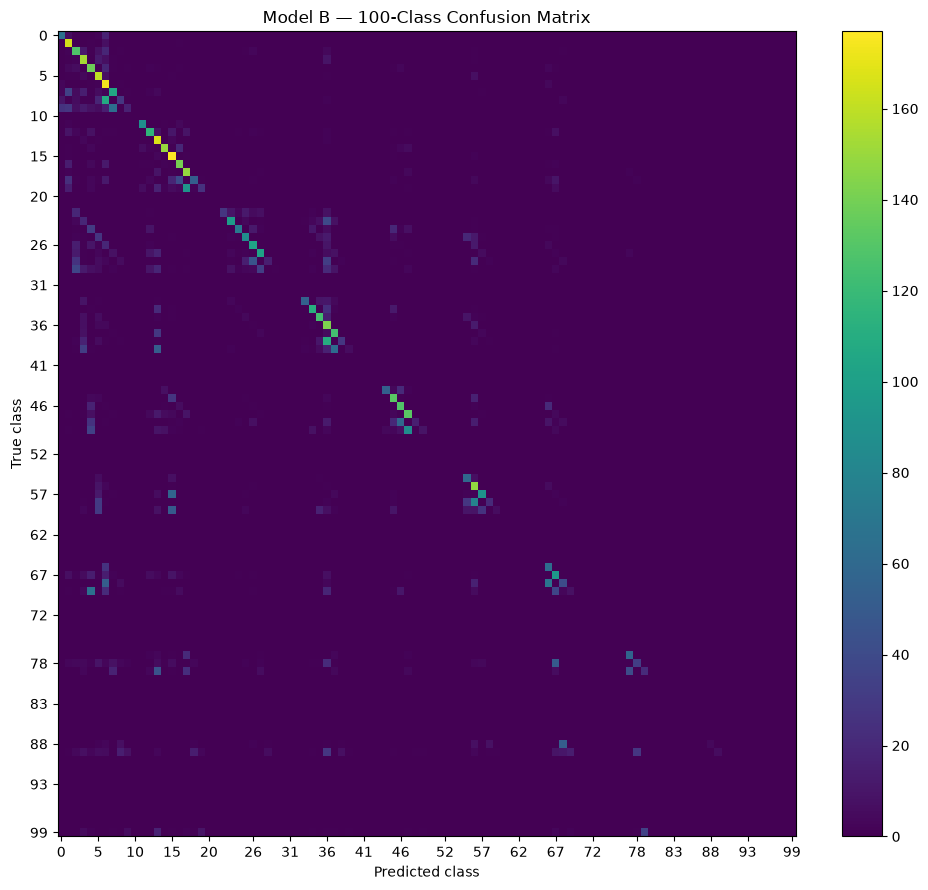

In [25]:

plot_confusion_matrix(
    results_b["confusion_matrix"],
    "Model B — 100-Class Confusion Matrix",
    max_labels=20
)


## 17. Find the most common classification confusions

In [26]:

def top_confusions(cm, top_n=20):
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)

    flat_indices = np.argsort(cm_copy.ravel())[::-1]

    rows = []
    used = 0

    for flat_idx in flat_indices:
        true_class, predicted_class = np.unravel_index(
            flat_idx, cm_copy.shape
        )

        count = cm_copy[true_class, predicted_class]

        if count <= 0:
            break

        rows.append({
            "True": f"{true_class:02d}",
            "Predicted": f"{predicted_class:02d}",
            "Count": int(count),
        })

        used += 1

        if used >= top_n:
            break

    return pd.DataFrame(rows)

print("Model A top confusions:")
display(top_confusions(results_a["confusion_matrix"]))

print("Model B top confusions:")
display(top_confusions(results_b["confusion_matrix"]))


Model A top confusions:


,True,Predicted,Count
0,29,27,11
1,25,23,10
2,02,03,10
3,12,27,8
4,01,07,8
5,49,44,7
6,22,23,7
7,23,33,6
8,78,18,6
9,35,33,6


Model B top confusions:


,True,Predicted,Count
0,38,36,110
1,08,06,108
2,19,17,91
3,49,47,86
4,58,56,79
5,68,66,68
6,69,04,65
7,09,07,64
8,39,37,62
9,48,46,59



# 18. Model size and training-time comparison

The assignment asks for parameter count, estimated model size on disk, training time per epoch and test accuracy.


In [27]:

path_a, size_a_kb, size_a_mb = save_model_size(
    model_a, "model_a_standard_cnn.pth"
)

path_b, size_b_kb, size_b_mb = save_model_size(
    model_b, "model_b_lightweight_cnn.pth"
)

custom_results = pd.DataFrame([
    {
        "Model": "Model A - Standard CNN",
        "Trainable Parameters": count_parameters(model_a),
        "Model Size (KB)": size_a_kb,
        "Model Size (MB)": size_a_mb,
        "Training Time / Epoch (s)": history_a["avg_epoch_time"],
        "Test Accuracy (%)": results_a["accuracy"] * 100,
        "Precision (%)": results_a["precision"] * 100,
        "Recall (%)": results_a["recall"] * 100,
    },
    {
        "Model": "Model B - Lightweight CNN",
        "Trainable Parameters": count_parameters(model_b),
        "Model Size (KB)": size_b_kb,
        "Model Size (MB)": size_b_mb,
        "Training Time / Epoch (s)": history_b["avg_epoch_time"],
        "Test Accuracy (%)": results_b["accuracy"] * 100,
        "Precision (%)": results_b["precision"] * 100,
        "Recall (%)": results_b["recall"] * 100,
    }
])

display(custom_results)

custom_results.to_csv(
    OUTPUT_DIR / "custom_model_results.csv",
    index=False
)


,Model,Trainable Parameters,Model Size (KB),Model Size (MB),Training Time / Epoch (s),Test Accuracy (%),Precision (%),Recall (%)
0,Model A - Standard CNN,560612,2194.520508,2.143086,52.268081,93.845298,93.879820,93.749967
1,Model B - Lightweight CNN,9741,47.732422,0.046614,51.972448,49.226489,60.063935,49.554560


# 9. Transfer Learning — MobileNetV2 and EfficientNet-B0

Fine-tuning of the two pre-trained architectures and their evaluation.



# 19. Lightweight SOTA models

The assignment asks for two pretrained lightweight architectures designed for mobile/edge computing.

We use:
1. **MobileNetV2**
2. **EfficientNet-B0**

Both are adapted to 64×64 input, grayscale images converted to 3 channels, and 100 output classes.

The pretrained ImageNet weights can be downloaded by torchvision. Internet access is required the first time this cell is run.

If downloading pretrained weights is impossible, set `USE_PRETRAINED = False`; however, pretrained weights are preferred for the assignment's fine-tuning requirement.


In [28]:

USE_PRETRAINED = True

sota_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

sota_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

sota_train_dataset = TwoDigitDataset(train_split, sota_train_transform)
sota_val_dataset = TwoDigitDataset(val_split, sota_transform)
sota_test_dataset = TwoDigitDataset(test_split, sota_transform)

sota_train_loader = DataLoader(
    sota_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

sota_val_loader = DataLoader(
    sota_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

sota_test_loader = DataLoader(
    sota_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("SOTA dataloaders ready.")


SOTA dataloaders ready.


In [29]:

def build_mobilenet(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    else:
        model = mobilenet_v2(weights=None)

    model.classifier[1] = nn.Linear(
        model.last_channel,
        num_classes
    )

    return model


def build_efficientnet(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    else:
        model = efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(
        in_features,
        num_classes
    )

    return model


mobilenet_model = build_mobilenet(pretrained=USE_PRETRAINED).to(device)
efficientnet_model = build_efficientnet(pretrained=USE_PRETRAINED).to(device)

print("MobileNetV2 parameters:", f"{count_all_parameters(mobilenet_model):,}")
print("EfficientNet-B0 parameters:", f"{count_all_parameters(efficientnet_model):,}")


MobileNetV2 parameters: 2,351,972
EfficientNet-B0 parameters: 4,135,648



## 20. Fine-tune MobileNetV2

All layers remain trainable, so this is fine-tuning rather than training only the new classifier.


MobileNetV2 | Epoch 01/20 | Train Loss: 3.6479 | Train Acc: 10.91% | Val Loss: 2.6246 | Val Acc: 28.45% | Time: 88.0s
MobileNetV2 | Epoch 02/20 | Train Loss: 1.9522 | Train Acc: 44.58% | Val Loss: 1.1164 | Val Acc: 68.14% | Time: 88.0s
MobileNetV2 | Epoch 03/20 | Train Loss: 1.0304 | Train Acc: 69.43% | Val Loss: 0.5856 | Val Acc: 82.70% | Time: 87.5s
MobileNetV2 | Epoch 04/20 | Train Loss: 0.6594 | Train Acc: 80.11% | Val Loss: 0.4078 | Val Acc: 88.03% | Time: 87.8s
MobileNetV2 | Epoch 05/20 | Train Loss: 0.4956 | Train Acc: 84.93% | Val Loss: 0.3027 | Val Acc: 90.78% | Time: 87.2s
MobileNetV2 | Epoch 06/20 | Train Loss: 0.4034 | Train Acc: 87.76% | Val Loss: 0.2510 | Val Acc: 92.24% | Time: 87.0s
MobileNetV2 | Epoch 07/20 | Train Loss: 0.3382 | Train Acc: 89.60% | Val Loss: 0.2149 | Val Acc: 93.34% | Time: 87.2s
MobileNetV2 | Epoch 08/20 | Train Loss: 0.2927 | Train Acc: 90.80% | Val Loss: 0.1811 | Val Acc: 94.13% | Time: 87.7s
MobileNetV2 | Epoch 09/20 | Train Loss: 0.2560 | Train A

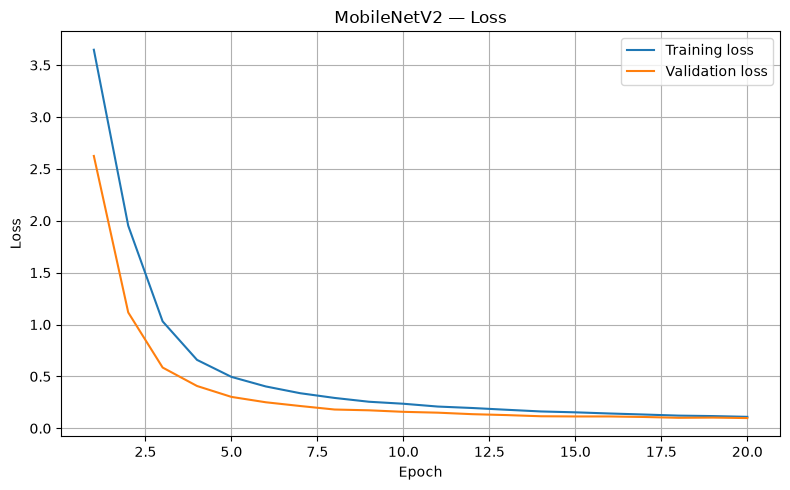

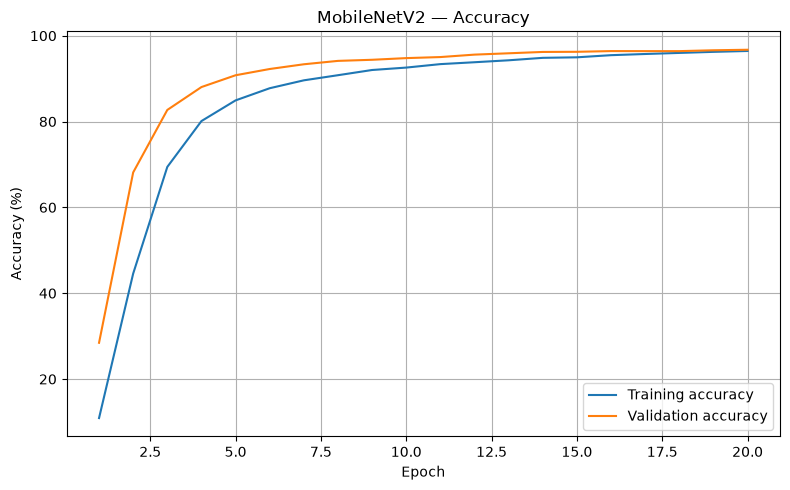


MobileNetV2 Test Results
Accuracy : 96.64%
Precision: 96.53% (macro)
Recall   : 96.70% (macro)


In [30]:

mobilenet_history = None
mobilenet_results = None
mobilenet_size_kb = None
mobilenet_size_mb = None

if RUN_MOBILENET:
    seed_everything()

    mobilenet_model, mobilenet_history = train_model(
        mobilenet_model,
        sota_train_loader,
        sota_val_loader,
        epochs=SOTA_EPOCHS,
        optimizer_name="adam",
        lr=1e-4 if USE_PRETRAINED else 1e-3,
        model_name="MobileNetV2",
    )

    plot_history(mobilenet_history, "MobileNetV2")

    mobilenet_results = evaluate_model(
        mobilenet_model,
        sota_test_loader,
        model_name="MobileNetV2"
    )

    _, mobilenet_size_kb, mobilenet_size_mb = save_model_size(
        mobilenet_model,
        "mobilenet_v2_two_digit.pth"
    )
else:
    print("MobileNetV2 stage skipped. Set RUN_MOBILENET=True to run it.")


## 21. Fine-tune EfficientNet-B0

EfficientNet-B0 | Epoch 01/20 | Train Loss: 3.5705 | Train Acc: 13.18% | Val Loss: 2.2649 | Val Acc: 38.02% | Time: 107.6s
EfficientNet-B0 | Epoch 02/20 | Train Loss: 1.5322 | Train Acc: 57.28% | Val Loss: 0.6151 | Val Acc: 82.27% | Time: 106.3s
EfficientNet-B0 | Epoch 03/20 | Train Loss: 0.6737 | Train Acc: 80.37% | Val Loss: 0.3071 | Val Acc: 90.92% | Time: 106.7s
EfficientNet-B0 | Epoch 04/20 | Train Loss: 0.4353 | Train Acc: 87.10% | Val Loss: 0.2215 | Val Acc: 93.15% | Time: 106.7s
EfficientNet-B0 | Epoch 05/20 | Train Loss: 0.3317 | Train Acc: 90.04% | Val Loss: 0.1685 | Val Acc: 94.71% | Time: 106.8s
EfficientNet-B0 | Epoch 06/20 | Train Loss: 0.2724 | Train Acc: 91.75% | Val Loss: 0.1353 | Val Acc: 95.74% | Time: 106.9s
EfficientNet-B0 | Epoch 07/20 | Train Loss: 0.2289 | Train Acc: 92.85% | Val Loss: 0.1273 | Val Acc: 96.03% | Time: 106.1s
EfficientNet-B0 | Epoch 08/20 | Train Loss: 0.2011 | Train Acc: 93.68% | Val Loss: 0.1145 | Val Acc: 96.32% | Time: 106.5s
EfficientNet-B0 

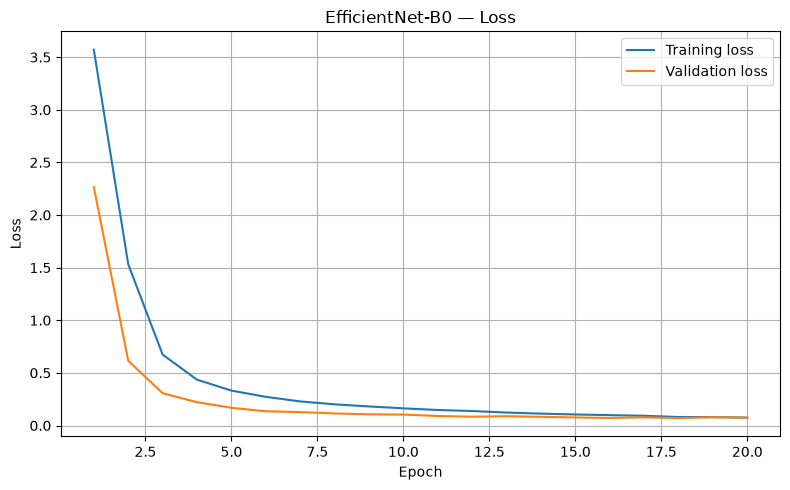

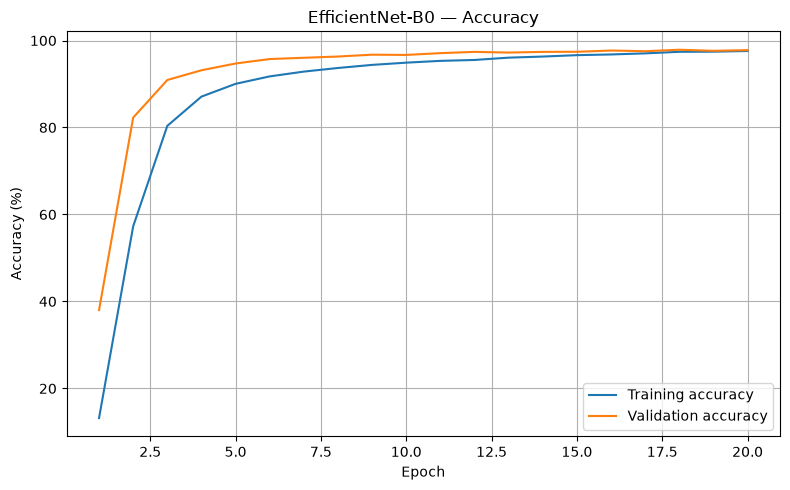


EfficientNet-B0 Test Results
Accuracy : 97.80%
Precision: 97.82% (macro)
Recall   : 97.78% (macro)


In [31]:

efficientnet_history = None
efficientnet_results = None
efficientnet_size_kb = None
efficientnet_size_mb = None

if RUN_EFFICIENTNET:
    seed_everything()

    efficientnet_model, efficientnet_history = train_model(
        efficientnet_model,
        sota_train_loader,
        sota_val_loader,
        epochs=SOTA_EPOCHS,
        optimizer_name="adam",
        lr=1e-4 if USE_PRETRAINED else 1e-3,
        model_name="EfficientNet-B0",
    )

    plot_history(efficientnet_history, "EfficientNet-B0")

    efficientnet_results = evaluate_model(
        efficientnet_model,
        sota_test_loader,
        model_name="EfficientNet-B0"
    )

    _, efficientnet_size_kb, efficientnet_size_mb = save_model_size(
        efficientnet_model,
        "efficientnet_b0_two_digit.pth"
    )
else:
    print("EfficientNet-B0 stage skipped. Set RUN_EFFICIENTNET=True to run it.")



# 22. Final comparison table

This table directly supports the assignment's final trade-off discussion.


In [32]:

comparison_rows = []

comparison_rows.append({
    "Model": "Model A - Standard CNN",
    "Parameters": count_parameters(model_a),
    "Size (KB)": size_a_kb,
    "Size (MB)": size_a_mb,
    "Time/Epoch (s)": history_a["avg_epoch_time"],
    "Accuracy (%)": results_a["accuracy"] * 100,
    "Precision (%)": results_a["precision"] * 100,
    "Recall (%)": results_a["recall"] * 100,
})

comparison_rows.append({
    "Model": "Model B - Lightweight CNN",
    "Parameters": count_parameters(model_b),
    "Size (KB)": size_b_kb,
    "Size (MB)": size_b_mb,
    "Time/Epoch (s)": history_b["avg_epoch_time"],
    "Accuracy (%)": results_b["accuracy"] * 100,
    "Precision (%)": results_b["precision"] * 100,
    "Recall (%)": results_b["recall"] * 100,
})

if mobilenet_results is not None:
    comparison_rows.append({
        "Model": "MobileNetV2",
        "Parameters": count_all_parameters(mobilenet_model),
        "Size (KB)": mobilenet_size_kb,
        "Size (MB)": mobilenet_size_mb,
        "Time/Epoch (s)": mobilenet_history["avg_epoch_time"],
        "Accuracy (%)": mobilenet_results["accuracy"] * 100,
        "Precision (%)": mobilenet_results["precision"] * 100,
        "Recall (%)": mobilenet_results["recall"] * 100,
    })

if efficientnet_results is not None:
    comparison_rows.append({
        "Model": "EfficientNet-B0",
        "Parameters": count_all_parameters(efficientnet_model),
        "Size (KB)": efficientnet_size_kb,
        "Size (MB)": efficientnet_size_mb,
        "Time/Epoch (s)": efficientnet_history["avg_epoch_time"],
        "Accuracy (%)": efficientnet_results["accuracy"] * 100,
        "Precision (%)": efficientnet_results["precision"] * 100,
        "Recall (%)": efficientnet_results["recall"] * 100,
    })

final_comparison = pd.DataFrame(comparison_rows)

display(
    final_comparison.style.format({
        "Parameters": "{:,.0f}",
        "Size (KB)": "{:.2f}",
        "Size (MB)": "{:.4f}",
        "Time/Epoch (s)": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
    })
)

final_comparison.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False
)


,Model,Parameters,Size (KB),Size (MB),Time/Epoch (s),Accuracy (%),Precision (%),Recall (%)
0,Model A - Standard CNN,"560,612",2194.52,2.1431,52.27,93.85,93.88,93.75
1,Model B - Lightweight CNN,"9,741",47.73,0.0466,51.97,49.23,60.06,49.55
2,MobileNetV2,"2,351,972",9431.07,9.2100,88.11,96.64,96.53,96.70
3,EfficientNet-B0,"4,135,648",16452.98,16.0674,107.37,97.80,97.82,97.78



# 23. Accuracy vs model size

This visualization helps explain the edge-device trade-off.

A good edge model should ideally have high accuracy while using relatively few parameters and a small model file.


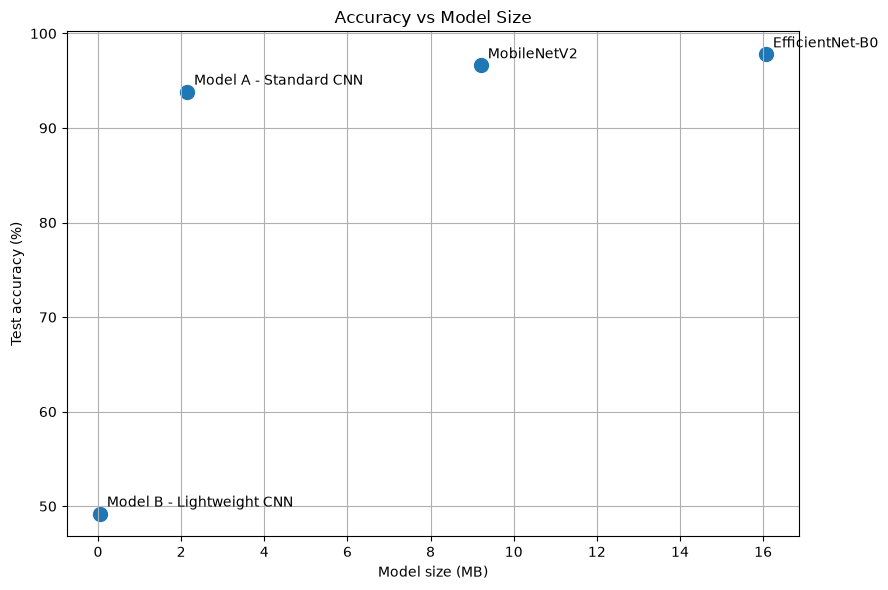

In [33]:

plt.figure(figsize=(9, 6))

plt.scatter(
    final_comparison["Size (MB)"],
    final_comparison["Accuracy (%)"],
    s=100
)

for _, row in final_comparison.iterrows():
    plt.annotate(
        row["Model"],
        (row["Size (MB)"], row["Accuracy (%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Model size (MB)")
plt.ylabel("Test accuracy (%)")
plt.title("Accuracy vs Model Size")
plt.grid(True)
plt.tight_layout()
plt.show()



# 24. Generate a concise results summary for the report

Run this cell after all experiments have completed. The output can be used while writing the report.


In [34]:

best_accuracy_row = final_comparison.loc[
    final_comparison["Accuracy (%)"].idxmax()
]

smallest_model_row = final_comparison.loc[
    final_comparison["Parameters"].idxmin()
]

print("REPORT SUMMARY")
print("=" * 70)

print(
    f"Highest test accuracy: {best_accuracy_row['Model']} "
    f"({best_accuracy_row['Accuracy (%)']:.2f}%)"
)

print(
    f"Smallest model by parameter count: "
    f"{smallest_model_row['Model']} "
    f"({smallest_model_row['Parameters']:,} parameters)"
)

print(
    f"Model B parameters: {count_parameters(model_b):,} "
    f"(must be <100,000)"
)

print(
    f"Model A average training time/epoch: "
    f"{history_a['avg_epoch_time']:.2f} s"
)

print(
    f"Model B average training time/epoch: "
    f"{history_b['avg_epoch_time']:.2f} s"
)


REPORT SUMMARY
Highest test accuracy: EfficientNet-B0 (97.80%)
Smallest model by parameter count: Model B - Lightweight CNN (9,741 parameters)
Model B parameters: 9,741 (must be <100,000)
Model A average training time/epoch: 52.27 s
Model B average training time/epoch: 51.97 s



# 25. Save important experiment outputs

The `outputs/` folder will contain model weights and CSV result tables.

Recommended files:

- `model_a_standard_cnn.pth`
- `model_b_lightweight_cnn.pth`
- `mobilenet_v2_two_digit.pth`
- `efficientnet_b0_two_digit.pth`
- `custom_model_results.csv`
- `final_model_comparison.csv`


In [35]:

print("Output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"{path.name:45s} {path.stat().st_size/1024:.2f} KB")


Output files:
custom_model_results.csv                      0.40 KB
efficientnet_b0_two_digit.pth                 16452.98 KB
final_model_comparison.csv                    0.61 KB
mobilenet_v2_two_digit.pth                    9431.07 KB
model_a_standard_cnn.pth                      2194.52 KB
model_b_lightweight_cnn.pth                   47.73 KB



# 26. Assignment report checklist

## Data Preparation
- [ ] Dataset description
- [ ] Two-digit classification explanation
- [ ] Example images
- [ ] 64×64 preprocessing
- [ ] 70/15/15 split
- [ ] 100 classes

## Model A
- [ ] Architecture diagram/table
- [ ] Kernel sizes
- [ ] Number of filters
- [ ] Fully connected units
- [ ] Trainable parameter count
- [ ] Activation-function justification

## Model B
- [ ] Depthwise-separable convolution explanation
- [ ] Architecture diagram/table
- [ ] Parameter count
- [ ] Proof that parameters <100,000
- [ ] Hardware-aware justification

## Optimizers
- [ ] Adam learning rate
- [ ] SGD result
- [ ] SGD + Momentum result
- [ ] Momentum discussion

## Custom CNN Evaluation
- [ ] 20+ epoch training
- [ ] Training/validation loss curves
- [ ] Accuracy
- [ ] Precision
- [ ] Recall
- [ ] Confusion matrix
- [ ] Model size
- [ ] Training time/epoch
- [ ] Model A vs Model B discussion

## SOTA
- [ ] MobileNetV2
- [ ] EfficientNet-B0
- [ ] Pretrained weights
- [ ] Fine-tuning method
- [ ] Parameter count
- [ ] Model size in MB
- [ ] Test performance

## Final Discussion
- [ ] Accuracy vs memory
- [ ] Computational cost
- [ ] Custom Model B advantages
- [ ] Custom Model B limitations
- [ ] SOTA advantages
- [ ] SOTA limitations
- [ ] Which model is best for an edge device and why

## GitHub
- [ ] Regular commits
- [ ] GitHub profile/repository link
- [ ] Clean commented code
- [ ] Final notebook



# 27. Suggested final discussion template

**Do not copy numerical values from this template. Replace the placeholders with your actual results.**

> Model A achieved **XX%** test accuracy with **XX** trainable parameters. Model B reduced the parameter count to **XX**, satisfying the sub-100k constraint, while achieving **XX%** test accuracy. This demonstrates the memory-efficiency advantage of depthwise-separable convolutions. However, the lightweight design may reduce feature-extraction capacity compared with the standard CNN.

> Among the tested optimizers, **XXX** produced the best validation performance. SGD with momentum showed **XXX** behavior compared with standard SGD. The momentum term helped/failed to help convergence in this experiment, as shown by the measured validation curves.

> MobileNetV2 and EfficientNet-B0 achieved **XX%** and **XX%** accuracy respectively. They contain substantially more parameters than the custom Model B, but pretrained feature representations can provide higher accuracy. Therefore, Model B offers a strong memory/computational advantage for extremely constrained devices, whereas a pretrained lightweight network may provide better accuracy when additional memory and compute are available.


# 12. Report Checklist

Use the outputs from this notebook to populate the LaTeX report.

- Dataset: 100 classes, 64×64 input, 70/15/15 split.
- Model A: standard CNN.
- Model B: depthwise-separable CNN with fewer than 100,000 trainable parameters.
- Optimizers: Adam, SGD, SGD + Momentum.
- Evaluation: accuracy, macro precision, macro recall, confusion matrix.
- Transfer learning: MobileNetV2 and EfficientNet-B0.
- Final comparison: parameters, model size, training time, and test metrics.
- Figures expected by the report: dataset_samples.png, model_a_curves.png,
  model_a_confusion_matrix.png, model_b_confusion_matrix.png, and
  accuracy_vs_size.png.
